# TP Exercices : GPT, LLMs et Capacités Émergentes

**ITS3 - Natural Language Processing**  
**Auteur :** Kenza BOUZIDI  
**Contact :** kenza.bouzidi.ext@u-pec.fr

---

## Instructions

Ce TP est à réaliser **individuellement**. Vous devez :
1. Compléter toutes les cellules marquées `# TODO`
2. Répondre aux questions dans les cellules Markdown prévues
3. Exécuter tout le notebook et vérifier que tout fonctionne
4. Soumettre le notebook complété (.ipynb)

**Barème indicatif :**
- Exercice 1 : 3 points
- Exercice 2 : 4 points
- Exercice 3 : 4 points
- Exercice 4 : 4 points
- Exercice 5 : 5 points

---

In [1]:
# Cellule d'initialisation - NE PAS MODIFIER
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter, defaultdict

# Seed pour reproductibilité
np.random.seed(42)
torch.manual_seed(42)

print("Environnement initialisé")

Environnement initialisé


---

# Exercice 1 : Tokenization BPE (3 points)

## 1.1 Implémentation de `get_pair_frequencies` (1 point)

Implémentez la fonction qui compte les fréquences de toutes les paires de tokens adjacents dans un corpus.

In [2]:
def get_pair_frequencies(corpus):
    """
    Compte les fréquences de toutes les paires de tokens adjacents.
    """
    pairs = Counter()
    
    # On parcourt chaque mot et sa fréquence dans le corpus
    for word, freq in corpus.items():
        # On découpe le mot en symboles (ex: 'l o w _' devient ['l', 'o', 'w', '_'])
        symbols = word.split()
        
        # On regarde chaque paire adjacente
        for i in range(len(symbols) - 1):
            # La paire est constituée du symbole i et du symbole suivant i+1
            pair = (symbols[i], symbols[i+1])
            # On ajoute la fréquence du mot au compteur de cette paire
            pairs[pair] += freq
            
    return pairs

In [3]:
# Test de votre fonction
test_corpus = {
    'l o w _': 5,
    'l o w e r _': 2,
    'n e w e s t _': 6
}

pairs = get_pair_frequencies(test_corpus)

# Vérifications
assert pairs[('l', 'o')] == 7, f"Erreur: ('l', 'o') devrait être 7, obtenu {pairs[('l', 'o')]}"
assert pairs[('e', 's')] == 6, f"Erreur: ('e', 's') devrait être 6, obtenu {pairs[('e', 's')]}"
assert pairs[('w', '_')] == 5, f"Erreur: ('w', '_') devrait être 5, obtenu {pairs[('w', '_')]}"

print("✅ Test passé !")
print(f"\nPaires trouvées : {dict(pairs)}")

✅ Test passé !

Paires trouvées : {('l', 'o'): 7, ('o', 'w'): 7, ('w', '_'): 5, ('w', 'e'): 8, ('e', 'r'): 2, ('r', '_'): 2, ('n', 'e'): 6, ('e', 'w'): 6, ('e', 's'): 6, ('s', 't'): 6, ('t', '_'): 6}


## 1.2 Implémentation de `merge_pair` (1 point)

Implémentez la fonction qui fusionne une paire de tokens dans tout le corpus.

In [4]:
def merge_pair(pair, corpus):
    """
    Fusionne une paire de tokens dans tout le corpus.
    """
    new_corpus = {}
    
    # 1. On construit la chaine à chercher (ex: "e s") avec un espace
    bigram = pair[0] + ' ' + pair[1]
    
    # 2. On construit la chaine de remplacement (ex: "es") sans espace
    replacement = pair[0] + pair[1]
    
    # 3. On parcourt tout le corpus pour faire le remplacement
    for word, freq in corpus.items():
        # La fonction .replace() cherche "e s" et met "es" à la place
        new_word = word.replace(bigram, replacement)
        new_corpus[new_word] = freq
        
    return new_corpus

In [5]:
# Test de votre fonction
test_corpus = {
    'l o w _': 5,
    'n e w e s t _': 6,
    'w i d e s t _': 3
}

merged = merge_pair(('e', 's'), test_corpus)

# Vérifications
assert 'n e w es t _' in merged, "Erreur: 'n e w es t _' devrait être dans le corpus"
assert 'w i d es t _' in merged, "Erreur: 'w i d es t _' devrait être dans le corpus"
assert merged['l o w _'] == 5, "Erreur: 'l o w _' ne devrait pas changer"

print("✅ Test passé !")
print(f"\nCorpus après fusion : {merged}")

✅ Test passé !

Corpus après fusion : {'l o w _': 5, 'n e w es t _': 6, 'w i d es t _': 3}


## 1.3 BPE Complet (1 point)

Utilisez vos fonctions pour entraîner un tokenizer BPE et répondre aux questions.

In [6]:
def train_bpe(words_freq, num_merges):
    """
    Entraîne un tokenizer BPE.
    """
    # 1. Initialiser le corpus (séparer en caractères + symbole de fin)
    corpus = {}
    for word, freq in words_freq.items():
        # 'low' -> 'l o w _'
        tokenized = ' '.join(list(word)) + ' _'
        corpus[tokenized] = freq
    
    merges = []
    
    # 2. Boucle d'entraînement
    for i in range(num_merges):
        # a. Calculer les fréquences de toutes les paires
        pairs = get_pair_frequencies(corpus)
        
        # Si plus aucune paire n'est disponible, on arrête
        if not pairs:
            break
            
        # b. Trouver la paire la plus fréquente (best_pair)
        # pairs.most_common(1) renvoie une liste [(('a','b'), 10)], on prend le premier élément [0][0]
        best_pair = pairs.most_common(1)[0][0]
        
        # c. Fusionner cette paire dans tout le corpus
        corpus = merge_pair(best_pair, corpus)
        
        # d. Enregistrer la fusion
        merges.append(best_pair)
        
        # (Optionnel) Petit print pour suivre ce qu'il se passe
        print(f"Fusion {i+1}/{num_merges} : {best_pair} fusionnés")
    
    return corpus, merges

In [7]:
# Entraînement sur un corpus
training_corpus = {
    'low': 5,
    'lower': 2,
    'newest': 6,
    'widest': 3,
    'lowest': 4
}

final_corpus, merges = train_bpe(training_corpus, num_merges=8)

print("📝 Fusions effectuées (dans l'ordre) :")
for i, merge in enumerate(merges):
    print(f"   {i+1}. {merge[0]} + {merge[1]} → {''.join(merge)}")

print(f"\n📚 Corpus final :")
for word, freq in final_corpus.items():
    print(f"   '{word}' : {freq}")

Fusion 1/8 : ('e', 's') fusionnés
Fusion 2/8 : ('es', 't') fusionnés
Fusion 3/8 : ('est', '_') fusionnés
Fusion 4/8 : ('l', 'o') fusionnés
Fusion 5/8 : ('lo', 'w') fusionnés
Fusion 6/8 : ('n', 'e') fusionnés
Fusion 7/8 : ('ne', 'w') fusionnés
Fusion 8/8 : ('new', 'est_') fusionnés
📝 Fusions effectuées (dans l'ordre) :
   1. e + s → es
   2. es + t → est
   3. est + _ → est_
   4. l + o → lo
   5. lo + w → low
   6. n + e → ne
   7. ne + w → new
   8. new + est_ → newest_

📚 Corpus final :
   'low _' : 5
   'low e r _' : 2
   'newest_' : 6
   'w i d est_' : 3
   'low est_' : 4


### Réponses à la Question 1.3

**a) Quelle est la première paire fusionnée ? Pourquoi ?**
La première paire fusionnée est **('e', 's')**. C'est parce qu'elle apparaît le plus souvent dans le corpus (dans *new**es**t* (6) + *wid**es**t* (3) + *low**es**t* (4) = 13 occurrences), contrairement à ('l', 'o') qui n'apparaît que 11 fois (dans *low* et *lower*).

**b) Comment le mot "lowest" est-il tokenisé après 8 fusions ?**
Il est tokenisé en deux tokens : `['low', 'est_']`.
L'algorithme a appris le mot racine "low" et le suffixe commun "est_".

**c) Quel avantage y a-t-il à ce que "lowest" et "newest" partagent des tokens ?**
Cela permet au modèle de **généraliser**. En comprenant que le suffixe `est_` (qui indique un superlatif) est partagé, le modèle pourra potentiellement comprendre le sens grammatical d'un nouveau mot finissant par "est" (comme *fastest*), même s'il ne l'a jamais vu entier, juste en analysant ses morceaux.

---

# Exercice 2 : Attention Causale (4 points)

## 2.1 Création du masque causal (1 point)

Implémentez la fonction qui crée un masque causal (triangulaire inférieur).

In [8]:
def create_causal_mask(seq_len):
    """
    Crée un masque causal pour l'attention.
    Le masque doit être 1 pour les positions autorisées (i >= j)
    et 0 pour les positions masquées (i < j).
    """
    # On crée une matrice de taille (seq_len, seq_len) remplie de 1
    # torch.tril (triangular lower) ne garde que la partie inférieure gauche (le passé)
    # Le reste est mis à zéro (le futur)
    mask = torch.tril(torch.ones(seq_len, seq_len))
    
    return mask

In [9]:
# Test
mask = create_causal_mask(4)
expected = torch.tensor([
    [1., 0., 0., 0.],
    [1., 1., 0., 0.],
    [1., 1., 1., 0.],
    [1., 1., 1., 1.]
])

assert torch.allclose(mask, expected), f"Erreur: masque incorrect\nObtenu:\n{mask}\nAttendu:\n{expected}"
print(" Test passé !")
print(f"\nMasque causal 4x4 :\n{mask}")

 Test passé !

Masque causal 4x4 :
tensor([[1., 0., 0., 0.],
        [1., 1., 0., 0.],
        [1., 1., 1., 0.],
        [1., 1., 1., 1.]])


## 2.2 Implémentation de l'attention (2 points)

Implémentez le mécanisme d'attention scaled dot-product avec masque.

In [10]:
def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Calcule l'attention scaled dot-product.
    """
    d_k = Q.size(-1)
    
    # 1. Calculer les scores : Q . K^T
    # On transpose les deux dernières dimensions de K (-2, -1) pour multiplier correctement
    scores = torch.matmul(Q, K.transpose(-2, -1))
    
    # 2. Diviser par sqrt(d_k) (Scaling pour la stabilité)
    scores = scores / np.sqrt(d_k)
    
    # 3. Appliquer le masque (si fourni)
    if mask is not None:
        # On met -1 milliard (-1e9) là où le masque vaut 0
        # Cela force le softmax à donner 0% de probabilité à ces endroits
        scores = scores.masked_fill(mask == 0, -1e9)
    
    # 4. Appliquer softmax sur la dernière dimension
    attention_weights = F.softmax(scores, dim=-1)
    
    # 5. Multiplier par V
    output = torch.matmul(attention_weights, V)
    
    return output, attention_weights

In [11]:
# Test de votre implémentation
torch.manual_seed(42)

batch_size, seq_len, d_k = 1, 4, 8
Q = torch.randn(batch_size, seq_len, d_k)
K = torch.randn(batch_size, seq_len, d_k)
V = torch.randn(batch_size, seq_len, d_k)
mask = create_causal_mask(seq_len)

output, attn_weights = scaled_dot_product_attention(Q, K, V, mask)

# Vérifications
assert output.shape == (batch_size, seq_len, d_k), f"Output shape incorrect: {output.shape}"
assert attn_weights.shape == (batch_size, seq_len, seq_len), f"Attn weights shape incorrect: {attn_weights.shape}"

# Vérifier que les poids somment à 1
row_sums = attn_weights.sum(dim=-1)
assert torch.allclose(row_sums, torch.ones_like(row_sums), atol=1e-5), "Les poids doivent sommer à 1"

# Vérifier que le masque fonctionne (positions futures = 0)
assert attn_weights[0, 0, 1] < 1e-6, "Position [0,1] devrait être masquée (≈0)"
assert attn_weights[0, 0, 0] > 0.9, "Position [0,0] devrait avoir tout le poids (≈1)"

print("Tous les tests passés !")
print(f"\nPoids d'attention :\n{attn_weights[0]}")

Tous les tests passés !

Poids d'attention :
tensor([[1.0000, 0.0000, 0.0000, 0.0000],
        [0.0585, 0.9415, 0.0000, 0.0000],
        [0.2114, 0.4180, 0.3706, 0.0000],
        [0.1926, 0.1803, 0.1955, 0.4316]])


## 2.3 Analyse de l'attention (1 point)

Visualisez et analysez les poids d'attention.

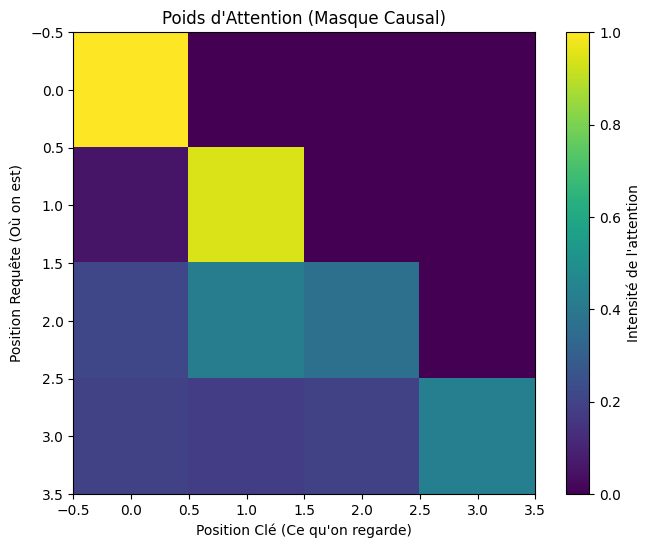

In [12]:
# Visualisation de la matrice d'attention
plt.figure(figsize=(8, 6))

# On convertit le tenseur en tableau numpy pour l'affichage
# On prend le premier élément du batch [0]
# cmap='viridis' ou 'Blues' pour les couleurs
plt.imshow(attn_weights[0].detach().numpy(), cmap='viridis')

# Ajout de la barre de couleur et des titres
plt.colorbar(label="Intensité de l'attention")
plt.title("Poids d'Attention (Masque Causal)")
plt.xlabel("Position Clé (Ce qu'on regarde)")
plt.ylabel("Position Requête (Où on est)")

# Affichage
plt.show()

### Réponses à la Question 2.3

**a) Pourquoi divise-t-on les scores par $\sqrt{d_k}$ avant le softmax ?**
Pour la **stabilité numérique**. Si les dimensions ($d_k$) sont grandes, le produit scalaire $Q \cdot K^T$ peut devenir très grand. Cela pousserait le Softmax dans des zones où les pentes (gradients) sont quasi nulles ("vanishing gradients"), ce qui empêcherait le réseau d'apprendre. La division ramène les valeurs à une échelle raisonnable.

**b) Que se passerait-il si on n'appliquait pas le masque causal pendant l'entraînement ?**
Le modèle pourrait **"tricher"** en regardant les mots futurs pour prédire le mot actuel. Il n'apprendrait pas la relation de cause à effet (prédire la suite) et serait inutile pour générer du texte, car lors de la génération réelle, le futur n'existe pas encore.

**c) Observez la ligne 0 de la matrice d'attention. Pourquoi le token 0 ne peut-il regarder que lui-même ?**
À la position 0 (le tout premier mot de la phrase), il n'y a **aucun passé**. Le masque causal met à $-\infty$ toutes les positions futures (1, 2, 3...). La seule position autorisée est 0. Le Softmax concentre donc 100% de la probabilité sur l'indice 0.

---

# Exercice 3 : Multi-Head Attention (4 points)

## 3.1 Implémentation (3 points)

Complétez l'implémentation de la Multi-Head Attention.

In [13]:
class MultiHeadAttention(nn.Module):
    """
    Multi-Head Attention Layer.
    """
    
    def __init__(self, d_model, num_heads):
        super().__init__()
        
        assert d_model % num_heads == 0, "d_model doit être divisible par num_heads"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # Dimension par tête
        
        # 1. Définition des couches linéaires (Projections)
        # Elles transforment l'entrée vers les espaces Q, K, V
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        
        # Couche finale pour mélanger les résultats des têtes
        self.W_o = nn.Linear(d_model, d_model)
    
    def split_heads(self, x):
        """
        Reshape pour multi-head: [batch, seq, d_model] -> [batch, heads, seq, d_k]
        """
        batch_size, seq_len, _ = x.size()
        
        # On redimensionne : (Batch, Seq, Heads, d_k)
        x = x.view(batch_size, seq_len, self.num_heads, self.d_k)
        
        # On transpose pour mettre les têtes en 2ème dimension : (Batch, Heads, Seq, d_k)
        # Cela permet de traiter chaque tête indépendamment
        return x.transpose(1, 2)
    
    def combine_heads(self, x):
        """
        Reshape inverse: [batch, heads, seq, d_k] -> [batch, seq, d_model]
        """
        batch_size, _, seq_len, _ = x.size()
        
        # On remet dans l'ordre : (Batch, Seq, Heads, d_k)
        x = x.transpose(1, 2).contiguous()
        
        # On recolle tout (concaténation) : (Batch, Seq, d_model)
        return x.view(batch_size, seq_len, self.d_model)
    
    def forward(self, x, mask=None):
        """
        Forward pass.
        """
        # 1. Projections linéaires
        Q = self.W_q(x)
        K = self.W_k(x)
        V = self.W_v(x)
        
        # 2. Séparer en têtes (Split)
        Q = self.split_heads(Q)
        K = self.split_heads(K)
        V = self.split_heads(V)
        
        # 3. Calculer l'attention (sur toutes les têtes en même temps)
        # output sera de forme [batch, heads, seq, d_k]
        attn_output, attention_weights = scaled_dot_product_attention(Q, K, V, mask)
        
        # 4. Recombiner les têtes (Concat)
        output = self.combine_heads(attn_output)
        
        # 5. Projection finale
        output = self.W_o(output)
        
        return output, attention_weights

In [14]:
# Test de votre implémentation
torch.manual_seed(42)

d_model = 64
num_heads = 4
seq_len = 8
batch_size = 2

mha = MultiHeadAttention(d_model, num_heads)
x = torch.randn(batch_size, seq_len, d_model)
mask = create_causal_mask(seq_len)

output, attn_weights = mha(x, mask)

# Vérifications
assert output.shape == (batch_size, seq_len, d_model), f"Output shape incorrect: {output.shape}"
assert attn_weights.shape == (batch_size, num_heads, seq_len, seq_len), f"Attn shape incorrect: {attn_weights.shape}"

print("Tests passés !")
print(f"Output shape: {output.shape}")
print(f"Attention weights shape: {attn_weights.shape}")

Tests passés !
Output shape: torch.Size([2, 8, 64])
Attention weights shape: torch.Size([2, 4, 8, 8])


## 3.2 Analyse (1 point)

Visualisez les poids d'attention pour différentes têtes et analysez.

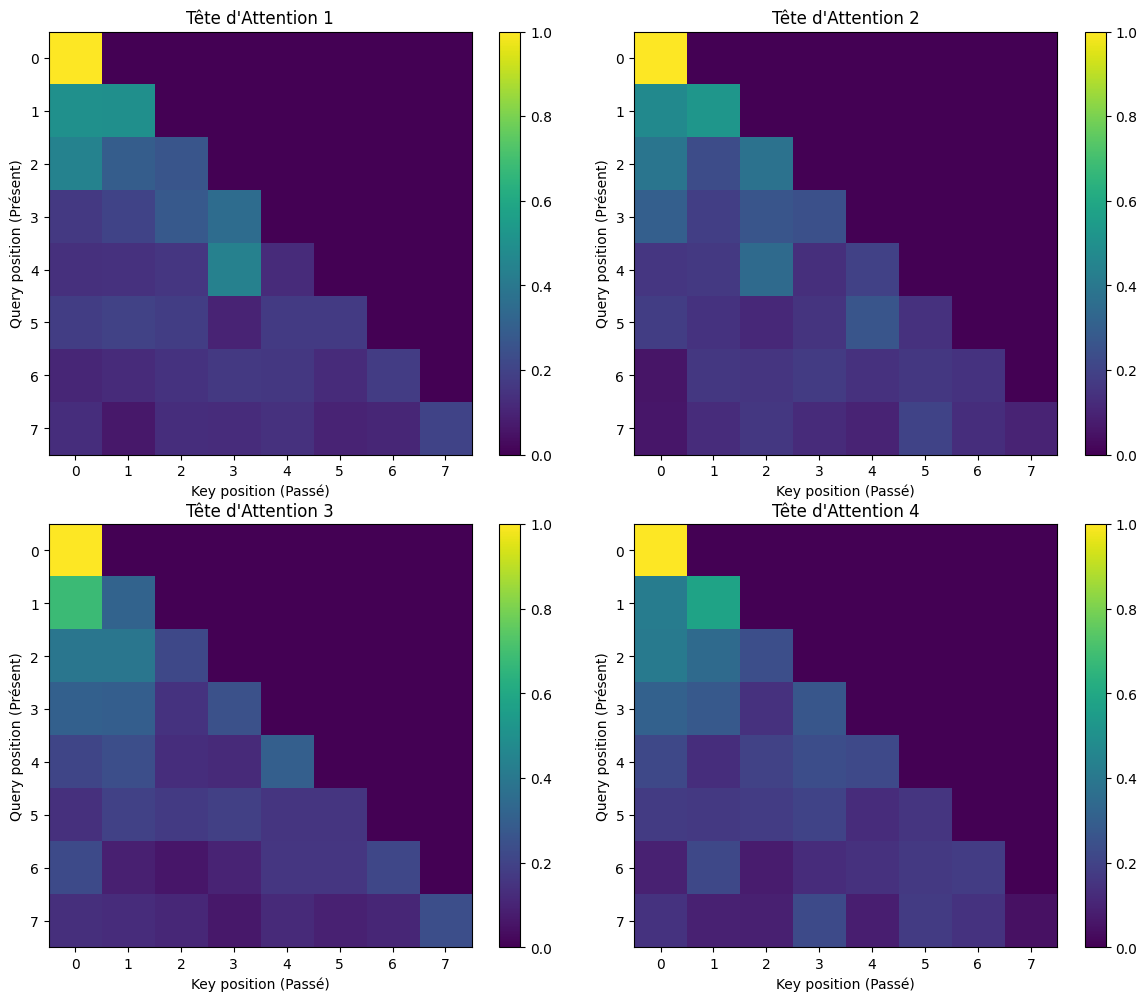

In [15]:
# Visualisation des 4 têtes pour le premier exemple du batch [0]
# On utilise les poids 'attn_weights' calculés juste avant dans la cellule de test
plt.figure(figsize=(12, 10))

# On boucle sur les 4 têtes (num_heads = 4)
for i in range(4):
    plt.subplot(2, 2, i+1) # Grille 2x2
    
    # On récupère la matrice d'attention de la tête i
    # .detach() est nécessaire pour convertir un tenseur PyTorch en tableau NumPy
    heatmap = attn_weights[0, i].detach().numpy()
    
    plt.imshow(heatmap, cmap='viridis')
    plt.title(f"Tête d'Attention {i+1}")
    plt.xlabel("Key position (Passé)")
    plt.ylabel("Query position (Présent)")
    plt.colorbar()

plt.tight_layout()
plt.show()

### Question 3.2 : Répondez à la question suivante

**a) Pourquoi utilise-t-on plusieurs têtes d'attention plutôt qu'une seule grande tête ?**

**Votre réponse :**
L'utilisation de plusieurs têtes (Multi-Head) permet au modèle de capturer **différents types de relations** simultanément.
Si nous n'avions qu'une seule tête, elle ferait une "moyenne" de toutes les attentions, ce qui rendrait l'information floue.

Avec plusieurs têtes, chacune peut se spécialiser :
* Une tête peut se focaliser sur la **grammaire** (ex: accorder le sujet et le verbe).
* Une autre sur le **sens** (ex: lier "pomme" à "manger").
* Une autre sur la **position** (ex: regarder le mot précédent).
Cela enrichit considérablement la compréhension du texte par le modèle.

---

# Exercice 4 : Prompting (4 points)

## 4.1 Conception de prompts (2 points)

Pour cet exercice, vous devez concevoir différents types de prompts pour une tâche de classification de sentiment sur des avis de produits technologiques.

In [3]:
# Avis à classifier
test_reviews = [
    "Ce téléphone est incroyable ! La batterie dure 2 jours et l'appareil photo est excellent.",
    "Très déçu par cet ordinateur. Il surchauffe constamment et le service client est inexistant.",
    "L'écran est correct mais le prix est trop élevé pour les fonctionnalités proposées.",
    "Meilleur achat de l'année ! Je recommande à 100%."
]

In [6]:
def create_zero_shot_prompt(review):
    """
    Crée un prompt zero-shot pour la classification de sentiment.
    """
    # On utilise une f-string (f"...") pour insérer la variable {review}
    prompt = f"""Tâche : Classifie le sentiment de l'avis suivant en 'Positif', 'Négatif' ou 'Mitigé'.

Avis : "{review}"
Sentiment :"""
    
    return prompt

In [7]:
def create_few_shot_prompt(review):
    """
    Crée un prompt few-shot pour la classification de sentiment.
    """
    prompt = f"""Tâche : Classifie le sentiment des avis produits.

Exemple 1
Avis : "La batterie ne tient pas la charge, c'est nul."
Sentiment : Négatif

Exemple 2
Avis : "Incroyable, je l'utilise tous les jours !"
Sentiment : Positif

Exemple 3
Avis : "Pas mal, mais un peu cher."
Sentiment : Mitigé

Avis à traiter
Avis : "{review}"
Sentiment :"""
    
    return prompt

In [8]:
# --- TEST MANUEL ---
print("TEST 1 : ZERO-SHOT")
print("-" * 20)
# On teste avec le premier avis de la liste (index 0)
print(create_zero_shot_prompt(test_reviews[0]))

print("\n\n") # Espaces pour lisibilité

print("TEST 2 : FEW-SHOT")
print("-" * 20)
# On teste avec un autre avis (index 1)
print(create_few_shot_prompt(test_reviews[1]))

TEST 1 : ZERO-SHOT
--------------------
Tâche : Classifie le sentiment de l'avis suivant en 'Positif', 'Négatif' ou 'Mitigé'.

Avis : "Ce téléphone est incroyable ! La batterie dure 2 jours et l'appareil photo est excellent."
Sentiment :



TEST 2 : FEW-SHOT
--------------------
Tâche : Classifie le sentiment des avis produits.

Exemple 1
Avis : "La batterie ne tient pas la charge, c'est nul."
Sentiment : Négatif

Exemple 2
Avis : "Incroyable, je l'utilise tous les jours !"
Sentiment : Positif

Exemple 3
Avis : "Pas mal, mais un peu cher."
Sentiment : Mitigé

Avis à traiter
Avis : "Très déçu par cet ordinateur. Il surchauffe constamment et le service client est inexistant."
Sentiment :


## 4.2 Chain-of-Thought (2 points)

Créez un prompt Chain-of-Thought pour un problème de raisonnement.

In [9]:
# On définit le problème (déjà fait dans ton notebook normalement, mais on le rappelle)
problem = """
Dans une classe de 30 élèves :
- 18 élèves aiment les mathématiques
- 15 élèves aiment la physique
- 8 élèves aiment les deux matières
Combien d'élèves n'aiment ni les mathématiques ni la physique ?
"""

# Le Prompt Chain-of-Thought force le modèle à détailler les étapes
cot_prompt = f"""Problème : {problem}

Instruction : Résous ce problème étape par étape. Ne donne pas la réponse immédiatement.
Suis ce raisonnement :
1. Liste les informations données (Total, Maths, Physique, Les deux).
2. Utilise la formule des ensembles : A U B = A + B - (A inter B).
3. Trouve le nombre d'élèves qui aiment au moins une matière.
4. Soustrais ce nombre du total pour trouver ceux qui n'aiment rien.

Ta réponse détaillée :"""

print("PROMPT CHAIN-OF-THOUGHT :")
print("=" * 50)
print(cot_prompt)

PROMPT CHAIN-OF-THOUGHT :
Problème : 
Dans une classe de 30 élèves :
- 18 élèves aiment les mathématiques
- 15 élèves aiment la physique
- 8 élèves aiment les deux matières
Combien d'élèves n'aiment ni les mathématiques ni la physique ?


Instruction : Résous ce problème étape par étape. Ne donne pas la réponse immédiatement.
Suis ce raisonnement :
1. Liste les informations données (Total, Maths, Physique, Les deux).
2. Utilise la formule des ensembles : A U B = A + B - (A inter B).
3. Trouve le nombre d'élèves qui aiment au moins une matière.
4. Soustrais ce nombre du total pour trouver ceux qui n'aiment rien.

Ta réponse détaillée :


### Question 4.2 : Répondez aux questions suivantes

**a) Quelle est la réponse correcte au problème ci-dessus ? Montrez votre raisonnement.**
La réponse est **5 élèves**.
*Raisonnement :*
* Total = 30
* Ceux qui aiment au moins une matière (Union) = Maths + Physique - Les deux
* Calcul : $18 + 15 - 8 = 25$ élèves aiment au moins une matière.
* Ceux qui n'aiment rien = Total - Union
* Calcul final : $30 - 25 = 5$ élèves.

**b) Pourquoi le Chain-of-Thought améliore-t-il les performances sur les problèmes de raisonnement ?**
Les LLM (comme GPT) prédisent le texte mot après mot. Si on leur demande la réponse directement, ils essaient de "deviner" le résultat final sans calculer.
En les forçant à générer des étapes intermédiaires (Chain-of-Thought), on leur donne l'équivalent de "temps de calcul" et de mémoire de travail, ce qui réduit considérablement les erreurs de logique.

**c) Dans quels cas le few-shot learning serait-il préférable au zero-shot ?**
Le **Few-Shot** est préférable quand :
1.  La tâche est complexe et difficile à expliquer par de simples instructions.
2.  On veut imposer un format de sortie très spécifique (ex: JSON, tableau).
3.  Le modèle échoue en Zero-Shot (ne comprend pas la consigne).

---

# Exercice 5 : RAG (Retrieval-Augmented Generation) (5 points)

## 5.1 Implémentation du Retriever (2 points)

Implémentez un système de recherche sémantique simple.

In [15]:
import numpy as np
from collections import Counter

class SimpleRetriever:
    """
    Système de recherche sémantique simple basé sur TF-IDF.
    """
    
    def __init__(self):
        self.documents = []
        self.vocab = {}  # Mapping mot -> index
        self.idf = {}    # Mapping mot -> score IDF
        self.doc_vectors = []
    
    def tokenize(self, text):
        """Tokenise simplement un texte en mots minuscules."""
        # On remplace la ponctuation simple pour éviter les soucis
        text = text.replace('.', '').replace(',', '').replace('?', '').replace('!', '')
        return text.lower().split()
    
    def compute_tf(self, tokens):
        """Calcule les fréquences de termes."""
        tf = Counter(tokens)
        total = len(tokens)
        if total == 0: return {}
        return {word: count/total for word, count in tf.items()}
    
    def fit(self, documents):
        """
        Indexe les documents.
        """
        self.documents = documents
        all_words = set()
        
        # 1. Construire le vocabulaire et compter DF (Document Frequency)
        doc_tokens = []
        df = Counter()
        
        for doc in documents:
            tokens = set(self.tokenize(doc)) # set pour compter 1 seule fois par doc
            doc_tokens.append(tokens)
            for token in tokens:
                df[token] += 1
                all_words.add(token)
        
        # On crée un index pour chaque mot (position dans le vecteur)
        self.vocab = {word: i for i, word in enumerate(sorted(list(all_words)))}
        
        # 2. Calculer l'IDF
        N = len(documents)
        for word, count in df.items():
            # Formule classique : log(N / (1 + df)) pour éviter la division par zéro
            self.idf[word] = np.log(N / (1 + count))
            
        # 3. Pré-calculer les vecteurs des documents
        self.doc_vectors = []
        for doc in documents:
            self.doc_vectors.append(self.vectorize(doc))
            
        self.doc_vectors = np.array(self.doc_vectors)
    
    def vectorize(self, text):
        """
        Convertit un texte en vecteur TF-IDF.
        """
        tokens = self.tokenize(text)
        tf = self.compute_tf(tokens)
        
        # Vecteur de zéros de la taille du vocabulaire
        vector = np.zeros(len(self.vocab))
        
        for word, freq in tf.items():
            if word in self.vocab:
                idx = self.vocab[word]
                # TF-IDF = TF * IDF
                vector[idx] = freq * self.idf[word]
                
        return vector
    
    def cosine_similarity(self, v1, v2):
        """
        Calcule la similarité cosinus entre deux vecteurs.
        """
        # Produit scalaire
        dot_product = np.dot(v1, v2)
        
        # Normes (longueurs) des vecteurs
        norm_v1 = np.linalg.norm(v1)
        norm_v2 = np.linalg.norm(v2)
        
        if norm_v1 == 0 or norm_v2 == 0:
            return 0.0
            
        return dot_product / (norm_v1 * norm_v2)
    
    def retrieve(self, query, top_k=3):
        """
        Récupère les k documents les plus pertinents.
        """
        # 1. Vectoriser la requête
        query_vec = self.vectorize(query)
        
        scores = []
        # 2. Calculer la similarité avec chaque document stocké
        for i, doc_vec in enumerate(self.doc_vectors):
            score = self.cosine_similarity(query_vec, doc_vec)
            scores.append((self.documents[i], score))
        
        # 3. Trier par score décroissant et prendre les top_k
        scores.sort(key=lambda x: x[1], reverse=True)
        
        return scores[:top_k]

In [16]:
# Base de connaissances pour tester
knowledge_base = [
    "Python est un langage de programmation créé par Guido van Rossum en 1991.",
    "Le deep learning est une branche du machine learning utilisant des réseaux de neurones profonds.",
    "GPT signifie Generative Pre-trained Transformer et a été créé par OpenAI.",
    "BERT est un modèle de langage bidirectionnel développé par Google.",
    "Les transformers utilisent un mécanisme d'attention pour traiter les séquences.",
    "PyTorch est une bibliothèque de deep learning développée par Facebook.",
    "TensorFlow est une bibliothèque de deep learning développée par Google.",
    "Le NLP ou traitement du langage naturel permet aux machines de comprendre le texte."
]

# Test du retriever
retriever = SimpleRetriever()
retriever.fit(knowledge_base)

# Requêtes de test
queries = [
    "Qu'est-ce que GPT ?",
    "Quelles sont les bibliothèques de deep learning ?",
    "Comment fonctionne l'attention ?"
]

for query in queries:
    print(f"\n🔍 Requête : {query}")
    print("-" * 50)
    results = retriever.retrieve(query, top_k=2)
    for doc, score in results:
        print(f"  [{score:.3f}] {doc}")


🔍 Requête : Qu'est-ce que GPT ?
--------------------------------------------------
  [0.324] GPT signifie Generative Pre-trained Transformer et a été créé par OpenAI.
  [0.000] Python est un langage de programmation créé par Guido van Rossum en 1991.

🔍 Requête : Quelles sont les bibliothèques de deep learning ?
--------------------------------------------------
  [0.485] Les transformers utilisent un mécanisme d'attention pour traiter les séquences.
  [0.227] TensorFlow est une bibliothèque de deep learning développée par Google.

🔍 Requête : Comment fonctionne l'attention ?
--------------------------------------------------
  [0.000] Python est un langage de programmation créé par Guido van Rossum en 1991.
  [0.000] Le deep learning est une branche du machine learning utilisant des réseaux de neurones profonds.


## 5.2 Génération du prompt RAG (2 points)

In [17]:
def create_rag_prompt(query, retrieved_docs):
    """
    Crée un prompt augmenté avec les documents récupérés.
    """
    # On rassemble tous les textes des documents trouvés en une seule chaine
    context_str = "\n".join([f"- {doc}" for doc, score in retrieved_docs])
    
    prompt = f"""Tu es un assistant intelligent. Utilise UNIQUEMENT les informations de contexte ci-dessous pour répondre à la question. Si la réponse n'est pas dans le contexte, dis "Je ne sais pas".

Contexte :
{context_str}

Question : {query}

Réponse :"""
    
    return prompt

In [18]:
# Test du prompt RAG
query = "Qu'est-ce que GPT ?"
# On simule que le retriever a trouvé ces documents
results = retriever.retrieve(query, top_k=2)

rag_prompt = create_rag_prompt(query, results)

print("PROMPT RAG GÉNÉRÉ :")
print("=" * 60)
print(rag_prompt)

PROMPT RAG GÉNÉRÉ :
Tu es un assistant intelligent. Utilise UNIQUEMENT les informations de contexte ci-dessous pour répondre à la question. Si la réponse n'est pas dans le contexte, dis "Je ne sais pas".

Contexte :
- GPT signifie Generative Pre-trained Transformer et a été créé par OpenAI.
- Python est un langage de programmation créé par Guido van Rossum en 1991.

Question : Qu'est-ce que GPT ?

Réponse :


## 5.3 Analyse (1 point)

### Question 5.3 : Répondez aux questions suivantes

**a) Quels sont les avantages du RAG par rapport à l'utilisation d'un LLM seul ?**
* **Actualité :** Le LLM a des connaissances figées (arrêtées à sa date d'entraînement). Le RAG permet de lui fournir des infos récentes (news, météo).
* **Données privées :** On peut faire travailler le LLM sur des documents d'entreprise confidentiels sans ré-entraîner le modèle.
* **Réduction des hallucinations :** En forçant le modèle à utiliser le contexte fourni ("Réponds uniquement avec le contexte"), on limite les inventions.

**b) Quelles sont les limites de l'approche TF-IDF par rapport aux embeddings (Sentence-BERT) ?**
TF-IDF cherche des **mots exacts**.
* Comme vu dans le TP, `"l'attention"` ne matche pas `"d'attention"` ou `"attention"`.
* Il ne comprend pas les synonymes (ex: "voiture" et "auto" sont vus comme totalement différents).
Les Embeddings (BERT) transforment les phrases en vecteurs de sens : ils auraient compris que "l'attention" et "d'attention" parlent de la même chose.

**c) Comment améliorer le système RAG pour des questions multi-documents ?**
Il faudrait utiliser un **Agent** (comme vu dans le TP précédent avec n8n !) capable de décomposer la question complexe en plusieurs sous-questions, de faire plusieurs recherches, puis de synthétiser les résultats (stratégie *Map-Reduce* ou *Chain-of-Thought*).

---

# Exercice Bonus : Capacités Émergentes (2 points)

Cet exercice bonus vaut des points supplémentaires.

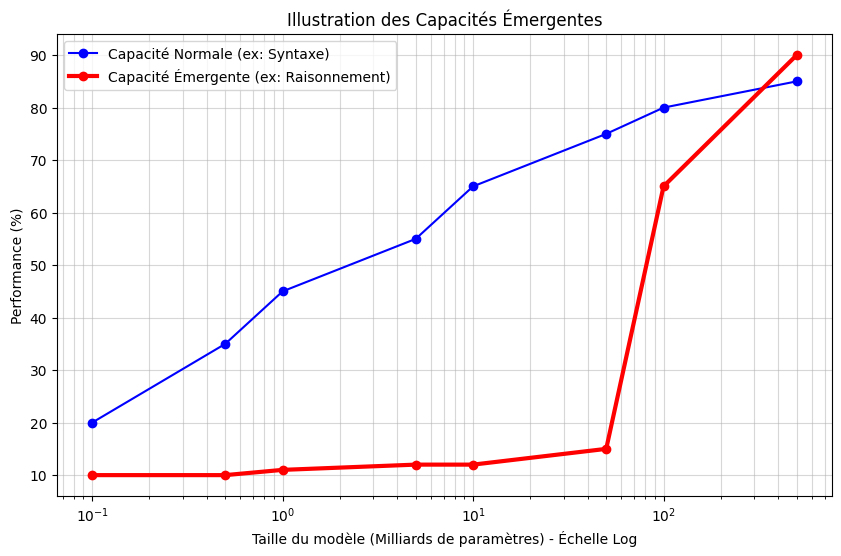

In [21]:
import matplotlib.pyplot as plt

# Données simulées
model_sizes = [0.1, 0.5, 1, 5, 10, 50, 100, 500]  # Milliards de paramètres

# 1. Capacité normale (Amélioration progressive, ex: traduction simple)
task_normal = [20, 35, 45, 55, 65, 75, 80, 85]

# 2. Capacité émergente (Rien... rien... rien... BOUM ça marche !)
# C'est typique des tâches de raisonnement complexe ou d'arithmétique
task_emergent = [10, 10, 11, 12, 12, 15, 65, 90]

# Visualisation
plt.figure(figsize=(10, 6))

# On utilise une échelle logarithmique en X car les tailles varient beaucoup
plt.semilogx(model_sizes, task_normal, 'o-', label='Capacité Normale (ex: Syntaxe)', color='blue')
plt.semilogx(model_sizes, task_emergent, 'o-', label='Capacité Émergente (ex: Raisonnement)', color='red', linewidth=3)

plt.grid(True, which="both", ls="-", alpha=0.5)
plt.xlabel("Taille du modèle (Milliards de paramètres) - Échelle Log")
plt.ylabel("Performance (%)")
plt.title("Illustration des Capacités Émergentes")
plt.legend()

plt.show()

### Analyse du Graphique : Capacités Normales vs Émergentes

Ce graphique met en évidence deux comportements distincts observés lors de l'augmentation de la taille des modèles de langage (Scaling Laws) :

**1. La Courbe Bleue : Capacité Normale (Progression Linéaire)**
* **Description :** La performance s'améliore de manière progressive et continue à mesure que la taille du modèle augmente.
* **Exemple :** Tâches de syntaxe, traduction simple ou reconnaissance de motifs.
* **Interprétation :** C'est le comportement classique du Machine Learning. Ajouter des paramètres réduit linéairement le taux d'erreur.

**2. La Courbe Rouge : Capacité Émergente (Transition de Phase)**
* **Description :** La performance reste proche de zéro (ou du niveau du hasard) pour les petits et moyens modèles. Soudainement, passé un certain **seuil critique** (ici entre 10 et 50 milliards de paramètres), la performance explose verticalement.
* **Exemple :** Raisonnement arithmétique, chaîne de pensée (Chain-of-Thought), compréhension de l'ironie ou codage informatique.
* **Interprétation :** C'est ce qu'on appelle l'**émergence**. Le modèle a besoin d'atteindre une "masse critique" de complexité pour réussir à combiner plusieurs concepts simples et résoudre un problème complexe. En dessous de ce seuil, il échoue totalement ; au-dessus, il réussit brillamment.

**Conclusion :**
Ce phénomène suggère que les très grands modèles (LLM) ne sont pas seulement des versions "plus performantes" des petits modèles, mais qu'ils acquièrent des **compétences qualitativement nouvelles** impossibles à prédire en observant seulement les petits modèles.

### Question Bonus

**Selon vous, les capacités émergentes sont-elles une vraie propriété ou un artefact ?**

C'est un sujet de débat intense, mais la tendance actuelle penche vers **l'artefact de mesure (Option 2)**.

**Argumentation :**
Des chercheurs (comme ceux de Stanford en 2023) ont montré que l'émergence brutale dépend souvent de **la façon dont on note** le modèle.
* Si on demande une réponse exacte (Tout ou Rien), la courbe semble "émergente" (le modèle a 0/20 tant qu'il n'est pas parfait, puis 20/20).
* Si on note la probabilité que le modèle trouve la bonne réponse (crédit partiel), on s'aperçoit que l'amélioration est en réalité **progressive et continue**.
L'effet de "saut quantique" est donc souvent une illusion créée par une métrique trop stricte.

---

# Soumission

Avant de soumettre, vérifiez que :

- [ ] Toutes les cellules de code s'exécutent sans erreur
- [ ] Toutes les questions Markdown ont été répondues
- [ ] Votre nom est dans la cellule ci-dessous

---

In [3]:
# Identifiez-vous
NOM = "MASSAR" 
PRENOM = "Izadine"

print(f"TP soumis par : {PRENOM} {NOM}")


TP soumis par : Izadine MASSAR


Image 1 générée : birads_dist.png
Image 2 générée : gantt_project.png


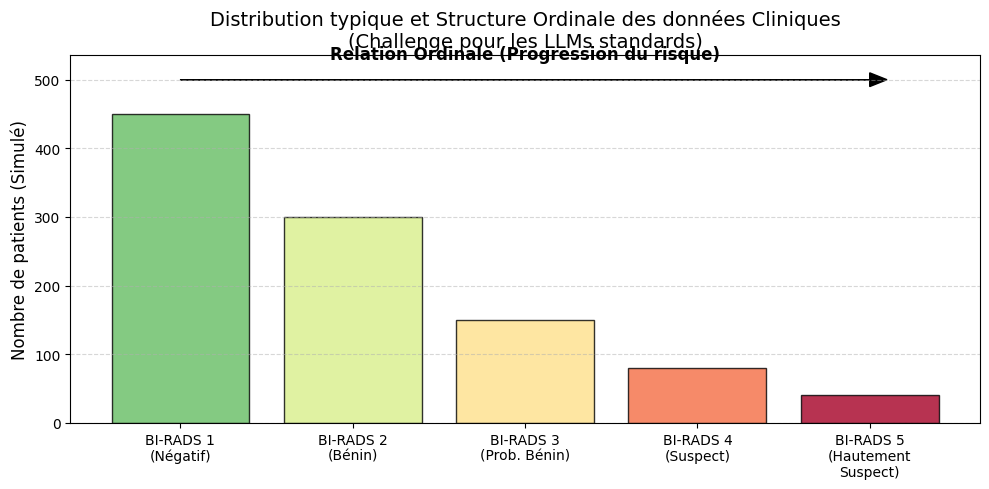

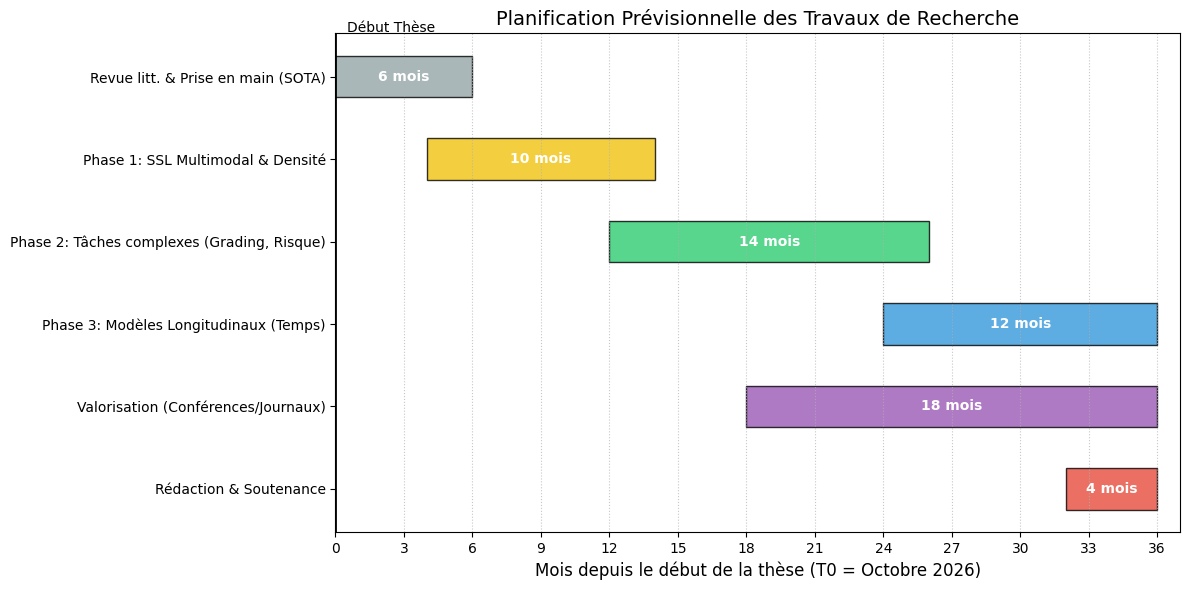

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches

# --- FIGURE 1 : Illustration de la nature Ordinale des données (BI-RADS) ---
def plot_birads_simulation():
    # Simulation de données cliniques typiques (Distribution déséquilibrée)
    categories = ['BI-RADS 1\n(Négatif)', 'BI-RADS 2\n(Bénin)', 'BI-RADS 3\n(Prob. Bénin)', 
                  'BI-RADS 4\n(Suspect)', 'BI-RADS 5\n(Hautement\nSuspect)']
    counts = [450, 300, 150, 80, 40] # Distribution typique en screening
    
    x = np.arange(len(categories))
    
    plt.figure(figsize=(10, 5))
    # Création d'un dégradé de couleur pour montrer l'aspect "Ordinal" (du vert au rouge)
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 1, len(categories)))
    
    bars = plt.bar(x, counts, color=colors, edgecolor='black', alpha=0.8)
    
    # Annotation de la relation d'ordre
    plt.arrow(0, 500, 4, 0, head_width=20, head_length=0.1, fc='k', ec='k')
    plt.text(2, 530, 'Relation Ordinale (Progression du risque)', ha='center', fontsize=12, fontweight='bold')
    
    plt.title("Distribution typique et Structure Ordinale des données Cliniques\n(Challenge pour les LLMs standards)", fontsize=14)
    plt.ylabel("Nombre de patients (Simulé)", fontsize=12)
    plt.xticks(x, categories, fontsize=10)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Sauvegarde
    plt.tight_layout()
    plt.savefig('birads_dist.png', dpi=300)
    print("Image 1 générée : birads_dist.png")

# --- FIGURE 2 : Diagramme de Gantt du plan de thèse ---
def plot_gantt_chart():
    fig, ax = plt.subplots(figsize=(12, 6))
    
    tasks = [
        ("Rédaction & Soutenance", 32, 4),
        ("Valorisation (Conférences/Journaux)", 18, 18),
        ("Phase 3: Modèles Longitudinaux (Temps)", 24, 12),
        ("Phase 2: Tâches complexes (Grading, Risque)", 12, 14),
        ("Phase 1: SSL Multimodal & Densité", 4, 10),
        ("Revue litt. & Prise en main (SOTA)", 0, 6),
    ]
    
    # Couleurs par phase
    colors = ['#e74c3c', '#9b59b6', '#3498db', '#2ecc71', '#f1c40f', '#95a5a6']
    
    for i, (task, start, duration) in enumerate(tasks):
        ax.barh(task, duration, left=start, height=0.5, align='center', color=colors[i], alpha=0.8, edgecolor='black')
        # Annotation de la durée
        ax.text(start + duration/2, i, f"{duration} mois", ha='center', va='center', color='white', fontweight='bold')

    ax.set_xlabel('Mois depuis le début de la thèse (T0 = Octobre 2026)', fontsize=12)
    ax.set_title('Planification Prévisionnelle des Travaux de Recherche', fontsize=14)
    ax.set_xlim(0, 37)
    ax.set_xticks(np.arange(0, 37, 3))
    ax.grid(axis='x', linestyle=':', alpha=0.7)
    
    # Ligne verticale "Aujourd'hui" (T0)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=2)
    plt.text(0.5, 5.5, 'Début Thèse', rotation=0, verticalalignment='bottom')

    plt.tight_layout()
    plt.savefig('gantt_project.png', dpi=300)
    print("Image 2 générée : gantt_project.png")

# Exécution
plot_birads_simulation()
plot_gantt_chart()

Image corrigée générée : birads_dist_corrected.png


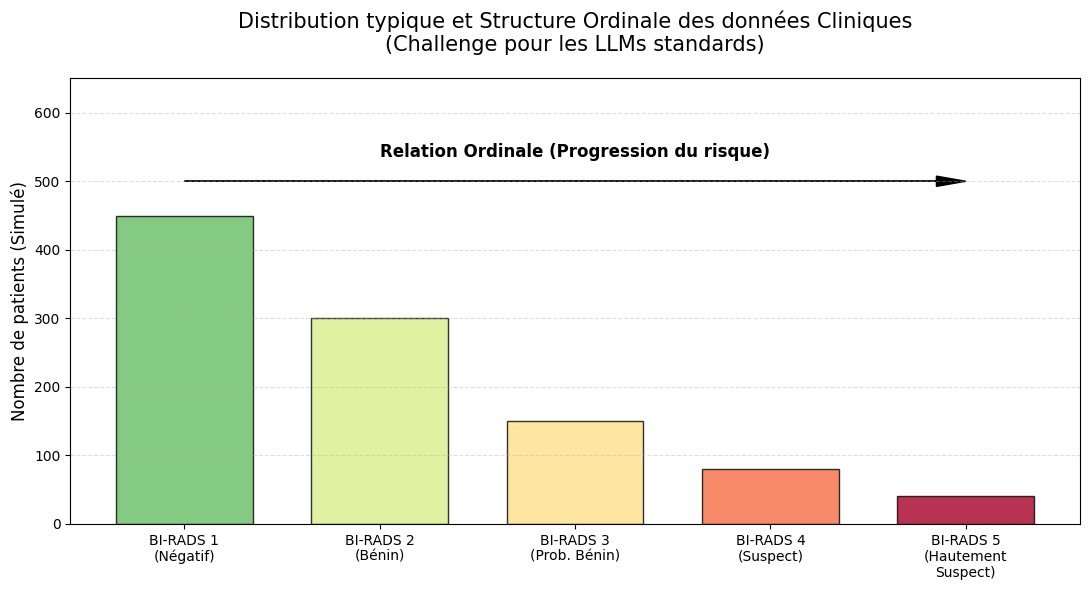

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def plot_birads_simulation_corrected():
    # Données
    categories = ['BI-RADS 1\n(Négatif)', 'BI-RADS 2\n(Bénin)', 'BI-RADS 3\n(Prob. Bénin)', 
                  'BI-RADS 4\n(Suspect)', 'BI-RADS 5\n(Hautement\nSuspect)']
    counts = [450, 300, 150, 80, 40] 
    
    x = np.arange(len(categories))
    
    plt.figure(figsize=(11, 6)) # Légèrement plus grand pour aérer
    
    # Couleurs
    colors = plt.cm.RdYlGn_r(np.linspace(0.2, 1, len(categories)))
    
    # Barres
    plt.bar(x, counts, color=colors, edgecolor='black', alpha=0.8, width=0.7)
    
    # --- CORRECTION MAJEURE ICI ---
    # On force l'axe Y à monter jusqu'à 600 pour laisser de la place au texte du haut
    plt.ylim(0, 650) 
    
    # La flèche (placée à y=500)
    plt.arrow(0, 500, 4, 0, head_width=15, head_length=0.15, fc='black', ec='black', length_includes_head=True)
    
    # Le texte au-dessus de la flèche (placé à y=530)
    # On ajoute un fond blanc (bbox) pour qu'il soit très lisible même si une ligne passe derrière
    plt.text(2, 530, 'Relation Ordinale (Progression du risque)', 
             ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')
    
    # Titres avec PADDING (pad=20) pour éviter le collage
    plt.title("Distribution typique et Structure Ordinale des données Cliniques\n(Challenge pour les LLMs standards)", 
              fontsize=15, pad=20)
    
    plt.ylabel("Nombre de patients (Simulé)", fontsize=12)
    plt.xticks(x, categories, fontsize=10)
    
    # Grille arrière
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    
    # Sauvegarde
    plt.tight_layout()
    plt.savefig('birads_dist_corrected.png', dpi=300)
    print("Image corrigée générée : birads_dist_corrected.png")

# Exécuter la fonction corrigée
plot_birads_simulation_corrected()